<h1 style="color:#2E86AB; font-family:Georgia; text-align:center; border-bottom: 3px solid #2E86AB; padding-bottom:10px;">
🤖 Modelo Predictivo de Deserción Escolar
</h1>

**Autor:** Eddy Luis  
**Fecha:** Mayo 2026  
**Herramientas:** Python · Scikit-learn · XGBoost · SHAP

---

## 📌 Descripción
Entrenamos un modelo de clasificación que predice el **nivel de riesgo de deserción** (muy_bajo, bajo, medio, alto) para cada centro educativo, usando características del centro y contexto de su distrito.

---

## 📋 Contenido de este Notebook

1. 📦 Importar Librerías y Cargar Datos
2. 🎯 Preparar Features y Target
3. ✂️ Train / Test Split
4. 🌲 Modelo 1: Random Forest
5. ⚡ Modelo 2: XGBoost
6. 🏆 Comparación de Modelos
7. 🔍 Interpretabilidad con SHAP
8. 💾 Guardar Modelo Final

---

<h2 style="color:#A23B72; font-family:Georgia;">
📦 1. Importar Librerías y Cargar Datos
</h2>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = Path("../data/processed")

df = pd.read_csv(PROCESSED_DIR / "dataset_modelo.csv")
print(f"Dataset cargado: {df.shape}")
print(f"\nDistribución de riesgo:\n{df['riesgo'].value_counts()}")

Dataset cargado: (18114, 37)

Distribución de riesgo:
riesgo
muy_bajo     7468
medio        4118
bajo         3641
sin_datos    2306
alto          581
Name: count, dtype: int64


<h2 style="color:#A23B72; font-family:Georgia;">
🎯 2. Preparar Features y Target
</h2>

**Target:** `riesgo` (muy_bajo / bajo / medio / alto)

**Features usadas:** características del centro + contexto del distrito + tendencia histórica. Se excluyen las tasas de abandono del período actual para evitar *data leakage* (ya que el target se derivó de ellas).

Se eliminan los 2,306 centros de educación de adultos (`sin_datos`) que no tienen tasa de abandono comparable.

In [14]:
# Filtrar centros sin datos (educación de adultos)
df_model = df[df["riesgo"] != "sin_datos"].copy()
print(f"Centros para modelado: {len(df_model)} (eliminados {len(df) - len(df_model)} de adultos)")

FEATURES = [
    "matricula",
    "es_publico",
    "tiene_inicial",
    "tiene_primario",
    "tiene_secundario",
    "num_niveles",
    "coordenadas longitud",
    "num_centros",
    "matricula_total",
    "matricula_promedio",
    "matricula_mediana",
    "pct_publico",
    "tendencia_abandono_sec",
    "abandono_sec_historico",
]

X = df_model[FEATURES].copy()
y = df_model["riesgo"].copy()

# Imputar nulos en coordenadas longitud (325 nulos) con la mediana
X["coordenadas longitud"] = X["coordenadas longitud"].fillna(X["coordenadas longitud"].median())

# Codificar target
le = LabelEncoder()
le.fit(["muy_bajo", "bajo", "medio", "alto"])
y_encoded = le.transform(y)

print(f"\nFeatures: {len(FEATURES)}")
print(f"Clases: {le.classes_}")
print(f"\nDistribución:\n{pd.Series(y_encoded).value_counts().sort_index()}")
print(f"  0={le.classes_[0]}, 1={le.classes_[1]}, 2={le.classes_[2]}, 3={le.classes_[3]}")
print(f"\nNulos en X: {X.isnull().sum().sum()}")

Centros para modelado: 15808 (eliminados 2306 de adultos)

Features: 14
Clases: ['alto' 'bajo' 'medio' 'muy_bajo']

Distribución:
0     581
1    3641
2    4118
3    7468
Name: count, dtype: int64
  0=alto, 1=bajo, 2=medio, 3=muy_bajo

Nulos en X: 0


<h2 style="color:#A23B72; font-family:Georgia;">
✂️ 3. Train / Test Split
</h2>

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"\nDistribución en train:")
for i, cls in enumerate(le.classes_):
    n = (y_train == i).sum()
    print(f"  {cls}: {n} ({n/len(y_train)*100:.1f}%)")

Train: (12646, 14)
Test:  (3162, 14)

Distribución en train:
  alto: 465 (3.7%)
  bajo: 2913 (23.0%)
  medio: 3294 (26.0%)
  muy_bajo: 5974 (47.2%)


<h2 style="color:#A23B72; font-family:Georgia;">
🌲 4. Modelo 1: Random Forest
</h2>

In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("=== Random Forest ===")
print(f"Accuracy: {rf.score(X_test, y_test):.4f}")
print(f"\nCross-validation (5-fold): {cross_val_score(rf, X, y_encoded, cv=5, scoring='accuracy').mean():.4f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=le.classes_)}")

=== Random Forest ===
Accuracy: 0.9968

Cross-validation (5-fold): 0.9952

              precision    recall  f1-score   support

        alto       0.98      1.00      0.99       116
        bajo       0.99      1.00      0.99       728
       medio       1.00      1.00      1.00       824
    muy_bajo       1.00      1.00      1.00      1494

    accuracy                           1.00      3162
   macro avg       0.99      1.00      1.00      3162
weighted avg       1.00      1.00      1.00      3162



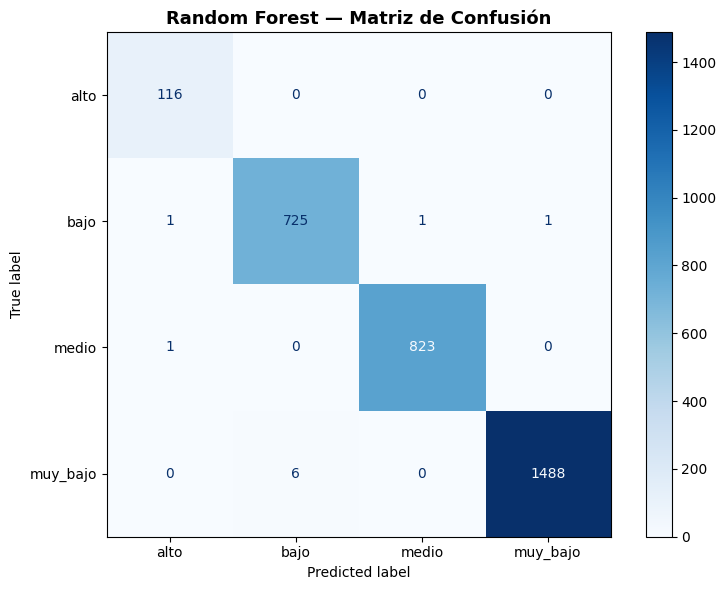

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=le.classes_, ax=ax, cmap="Blues"
)
ax.set_title("Random Forest — Matriz de Confusión", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

<h2 style="color:#A23B72; font-family:Georgia;">
⚡ 5. Modelo 2: XGBoost
</h2>

In [18]:
# Calcular pesos para clases desbalanceadas
from collections import Counter
counts = Counter(y_train)
total = len(y_train)
sample_weights = np.array([total / (len(counts) * counts[c]) for c in y_train])

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    verbosity=0,
)
xgb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb.predict(X_test)
print("=== XGBoost ===")
print(f"Accuracy: {xgb.score(X_test, y_test):.4f}")
print(f"\nCross-validation (5-fold): {cross_val_score(xgb, X, y_encoded, cv=5, scoring='accuracy').mean():.4f}")
print(f"\n{classification_report(y_test, y_pred_xgb, target_names=le.classes_)}")

=== XGBoost ===
Accuracy: 0.9997

Cross-validation (5-fold): 0.9996

              precision    recall  f1-score   support

        alto       1.00      1.00      1.00       116
        bajo       1.00      1.00      1.00       728
       medio       1.00      1.00      1.00       824
    muy_bajo       1.00      1.00      1.00      1494

    accuracy                           1.00      3162
   macro avg       1.00      1.00      1.00      3162
weighted avg       1.00      1.00      1.00      3162



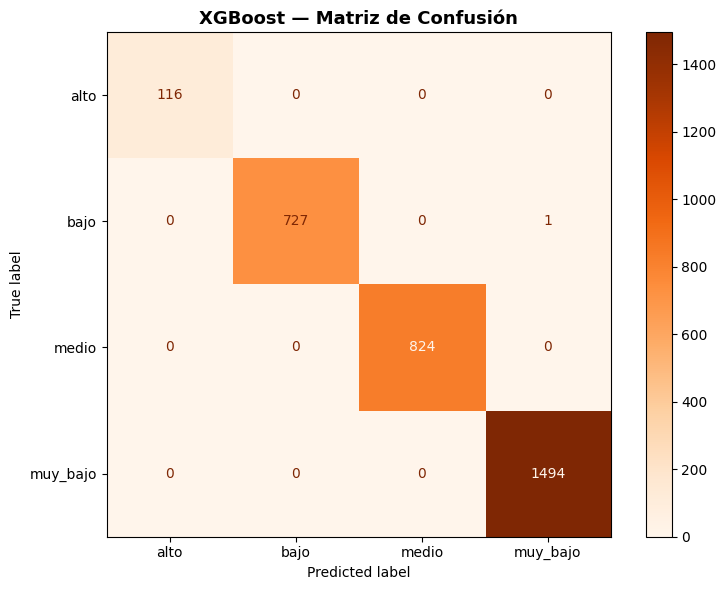

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, display_labels=le.classes_, ax=ax, cmap="Oranges"
)
ax.set_title("XGBoost — Matriz de Confusión", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

<h2 style="color:#A23B72; font-family:Georgia;">
🏆 6. Comparación de Modelos
</h2>

In [20]:
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    "Modelo": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
    ],
    "F1 Macro": [
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_xgb, average="macro"),
    ],
    "F1 Weighted": [
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_xgb, average="weighted"),
    ],
}).round(4)

print(results.to_string(index=False))

best_model_name = results.loc[results["F1 Macro"].idxmax(), "Modelo"]
best_model = rf if best_model_name == "Random Forest" else xgb
best_pred = y_pred_rf if best_model_name == "Random Forest" else y_pred_xgb
print(f"\n→ Mejor modelo por F1 Macro: {best_model_name}")

       Modelo  Accuracy  F1 Macro  F1 Weighted
Random Forest    0.9968    0.9954       0.9968
      XGBoost    0.9997    0.9997       0.9997

→ Mejor modelo por F1 Macro: XGBoost


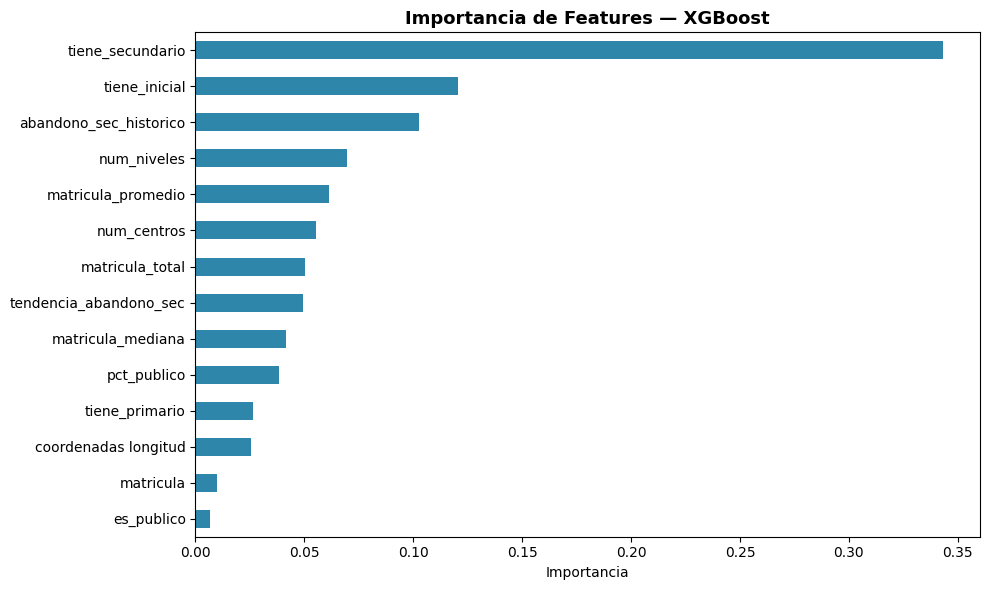

In [21]:
# Feature importance del mejor modelo
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    importances.plot(kind="barh", ax=ax, color="#2E86AB")
    ax.set_title(f"Importancia de Features — {best_model_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()

<h2 style="color:#A23B72; font-family:Georgia;">
🔍 7. Interpretabilidad con SHAP
</h2>

SHAP values shape: (4, 500, 14)
Clases: ['alto' 'bajo' 'medio' 'muy_bajo']


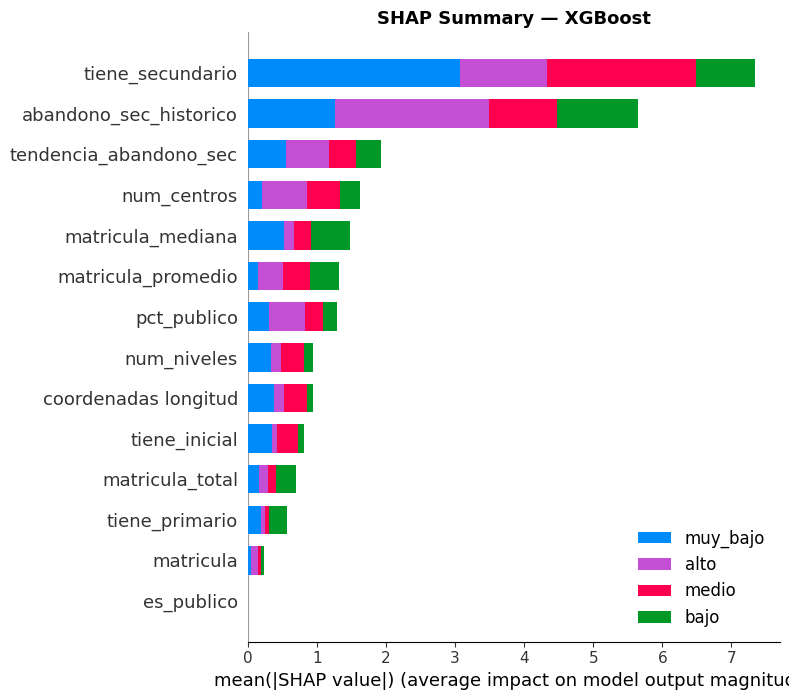

In [22]:
# SHAP con una muestra para velocidad
X_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

# Para multi-clase: shap_values es lista de arrays o array 3D
if isinstance(shap_values, list):
    shap_arr = np.array(shap_values)  # (n_classes, n_samples, n_features)
else:
    shap_arr = shap_values
    if shap_arr.ndim == 3 and shap_arr.shape[0] == len(le.classes_):
        pass  # ya es (n_classes, n_samples, n_features)
    elif shap_arr.ndim == 3 and shap_arr.shape[2] == len(le.classes_):
        shap_arr = shap_arr.transpose(2, 0, 1)  # -> (n_classes, n_samples, n_features)

print(f"SHAP values shape: {shap_arr.shape}")
print(f"Clases: {le.classes_}")

# Barplot global de importancia media por clase
shap.summary_plot(
    [shap_arr[i] for i in range(len(le.classes_))],
    X_sample,
    class_names=le.classes_,
    show=False,
)
plt.title(f"SHAP Summary — {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

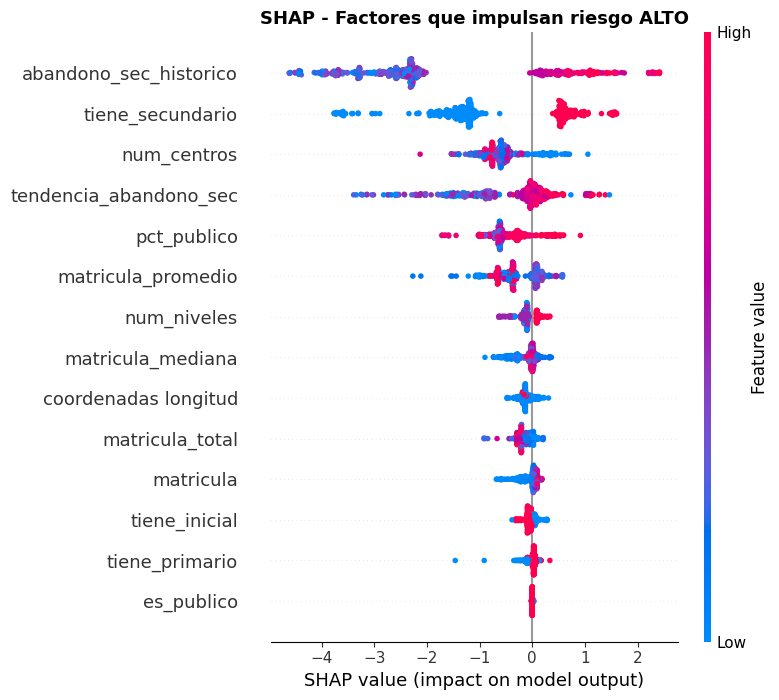

In [23]:
# SHAP para la clase "alto" (la mas critica)
alto_idx = list(le.classes_).index("alto")

shap.summary_plot(shap_arr[alto_idx], X_sample, feature_names=FEATURES, show=False)
plt.title("SHAP - Factores que impulsan riesgo ALTO", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

<h2 style="color:#A23B72; font-family:Georgia;">
💾 8. Guardar Modelo Final
</h2>

In [24]:
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, OUTPUT_DIR / "modelo_desercion.joblib")
joblib.dump(le, OUTPUT_DIR / "label_encoder.joblib")

# Guardar predicciones en el dataset
df_model["riesgo_predicho"] = le.inverse_transform(best_model.predict(X))
df_model.to_csv(PROCESSED_DIR / "dataset_con_predicciones.csv", index=False)

print(f"Modelo guardado: outputs/modelo_desercion.joblib")
print(f"Encoder guardado: outputs/label_encoder.joblib")
print(f"Dataset con predicciones: data/processed/dataset_con_predicciones.csv")
print(f"\nFeatures del modelo: {FEATURES}")

Modelo guardado: outputs/modelo_desercion.joblib
Encoder guardado: outputs/label_encoder.joblib
Dataset con predicciones: data/processed/dataset_con_predicciones.csv

Features del modelo: ['matricula', 'es_publico', 'tiene_inicial', 'tiene_primario', 'tiene_secundario', 'num_niveles', 'coordenadas longitud', 'num_centros', 'matricula_total', 'matricula_promedio', 'matricula_mediana', 'pct_publico', 'tendencia_abandono_sec', 'abandono_sec_historico']
